In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=sns.load_dataset('penguins')

In [41]:
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [42]:
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [43]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [44]:
df['body_mass_g'] = df['body_mass_g'].fillna(df.groupby('species')['body_mass_g'].transform('median'))
df['flipper_length_mm'] = df['flipper_length_mm'].fillna(df.groupby('species')['flipper_length_mm'].transform('median'))
df['bill_length_mm'] = df['bill_length_mm'].fillna(df.groupby('species')['bill_length_mm'].transform('median'))
df['bill_depth_mm'] = df['bill_depth_mm'].fillna(df.groupby('species')['bill_depth_mm'].transform('median'))
df.isnull().sum()

species               0
island                0
bill_length_mm        0
bill_depth_mm         0
flipper_length_mm     0
body_mass_g           0
sex                  11
dtype: int64

In [45]:
df['sex'] = df.groupby('species')['sex'].transform(lambda x: x.fillna(x.mode()[0]))
df.isnull().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

<Axes: xlabel='bill_length_mm', ylabel='flipper_length_mm'>

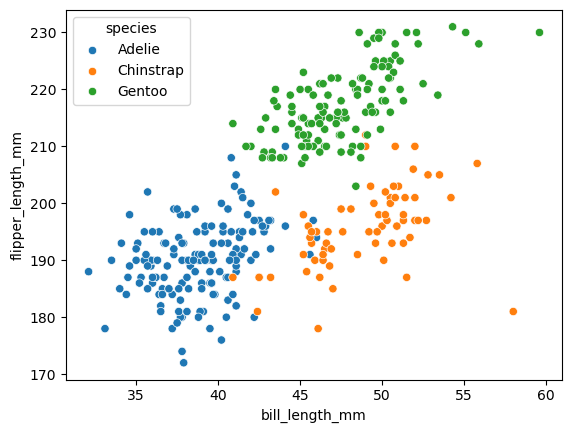

In [46]:
sns.scatterplot(x="bill_length_mm", y="flipper_length_mm", data=df, hue="species")

In [47]:
from sklearn.linear_model import LogisticRegression

In [48]:
X = df.drop("species",axis = 1)
y = df["species"]

In [49]:
X

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Torgersen,38.8,18.4,190.0,3700.0,Female
4,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...
339,Biscoe,47.3,15.0,216.0,5000.0,Male
340,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Biscoe,45.2,14.8,212.0,5200.0,Female


In [50]:
X = df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g','sex']]
X
X = pd.get_dummies(X, columns=['sex'], drop_first=True)
X

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex_Male
0,39.1,18.7,181.0,3750.0,True
1,39.5,17.4,186.0,3800.0,False
2,40.3,18.0,195.0,3250.0,False
3,38.8,18.4,190.0,3700.0,False
4,36.7,19.3,193.0,3450.0,False
...,...,...,...,...,...
339,47.3,15.0,216.0,5000.0,True
340,46.8,14.3,215.0,4850.0,False
341,50.4,15.7,222.0,5750.0,True
342,45.2,14.8,212.0,5200.0,False


In [52]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

y = LabelEncoder().fit_transform(df['species'])


In [53]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

In [54]:
X

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex_Male
0,39.1,18.7,181.0,3750.0,True
1,39.5,17.4,186.0,3800.0,False
2,40.3,18.0,195.0,3250.0,False
3,38.8,18.4,190.0,3700.0,False
4,36.7,19.3,193.0,3450.0,False
...,...,...,...,...,...
339,47.3,15.0,216.0,5000.0,True
340,46.8,14.3,215.0,4850.0,False
341,50.4,15.7,222.0,5750.0,True
342,45.2,14.8,212.0,5200.0,False


In [55]:
from sklearn.model_selection import train_test_split

In [56]:
x_train, x_test, y_train,y_test = train_test_split(X,y,test_size = 0.2)

In [57]:
lr = LogisticRegression()

In [58]:
lr.fit(x_train,y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [59]:
y_pred = lr.predict(x_test)

In [60]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))
##adi logistic regressio ile netimeiz

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        30
           1       0.93      0.93      0.93        15
           2       1.00      1.00      1.00        24

    accuracy                           0.97        69
   macro avg       0.97      0.97      0.97        69
weighted avg       0.97      0.97      0.97        69



In [61]:
from sklearn.preprocessing import PolynomialFeatures
pf = PolynomialFeatures(degree = 3)

In [62]:
x_train_transformed = pf.fit_transform(x_train)
x_test_transformed = pf.fit_transform(x_test)

In [63]:
x_train_data = pd.DataFrame(data = x_train_transformed)
x_test_data = pd.DataFrame(data = x_test_transformed)

In [64]:
lr = LogisticRegression(C = 3)

In [65]:
lr.fit(x_train_data, y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,3
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [66]:
y_pred = lr.predict(x_test_data)

In [67]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.93      0.97        15
           2       1.00      1.00      1.00        24

    accuracy                           0.99        69
   macro avg       0.99      0.98      0.98        69
weighted avg       0.99      0.99      0.99        69



In [68]:
from sklearn.model_selection import GridSearchCV
parameter_grid = {"penalty" : ["l1","l2",None],
              "C" : [0.5,1,2,3,0.1],
              "max_iter" :[100,200,300,1000,500]
                }

log_reg_cv = GridSearchCV(LogisticRegression() , param_grid = parameter_grid, cv = 5)

In [69]:
log_reg_cv.fit(x_train_data, y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also re

,estimator,LogisticRegression()
,param_grid,"{'C': [0.5, 1, ...], 'max_iter': [100, 200, ...], 'penalty': ['l1', 'l2', ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [71]:
log_reg_cv.best_params_
##gorek en yaxsi parmetrller nedir ki accurancy yuxair olsun onalri tetbiq edende

{'C': 0.1, 'max_iter': 200, 'penalty': 'l2'}

In [72]:
log_reg_cv.best_score_

np.float64(0.9818181818181818)

In [73]:
final_model = LogisticRegression(C= 0.1 , max_iter = 200, penalty ='l2')

In [74]:
final_model.fit(x_train_data,y_train)
y_pred = final_model.predict(x_test_data)

In [75]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.93      0.97        15
           2       1.00      1.00      1.00        24

    accuracy                           0.99        69
   macro avg       0.99      0.98      0.98        69
weighted avg       0.99      0.99      0.99        69



In [76]:
from sklearn.svm import SVC 
#indi de SVm ile baxaq

In [77]:
svm = SVC(kernel = "rbf")

In [79]:
svm.fit(x_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [80]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.93      0.97        15
           2       1.00      1.00      1.00        24

    accuracy                           0.99        69
   macro avg       0.99      0.98      0.98        69
weighted avg       0.99      0.99      0.99        69



In [81]:
parameter_grid = {"C" : [0.1, 0.5, 1, 2 ,3], "kernel":["sigmoid", "poly","rbf"], "degree":[2,3,4,1,5] }

In [93]:
svm_grid_search = GridSearchCV(SVC(), param_grid = parameter_grid, cv= 5,n_jobs = 1) 

In [94]:
svm_grid_search.fit(x_train,y_train)


,estimator,SVC()
,param_grid,"{'C': [0.1, 0.5, ...], 'degree': [2, 3, ...], 'kernel': ['sigmoid', 'poly', ...]}"
,scoring,None
,n_jobs,1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.1


In [95]:
svm_grid_search.best_params_

{'C': 0.1, 'degree': 2, 'kernel': 'poly'}

In [109]:
svm_grid_search.best_score_

np.float64(0.7418181818181818)

In [156]:
final_svm = SVC(C= 0.1, kernel="poly",degree=2)

In [157]:
final_svm.fit(x_train,y_train)

,C,0.1
,kernel,'poly'
,degree,2
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [158]:
y_pred = final_svm.predict(x_test)

In [159]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.59      0.97      0.73        30
           1       0.00      0.00      0.00        15
           2       0.95      0.79      0.86        24

    accuracy                           0.70        69
   macro avg       0.51      0.59      0.53        69
weighted avg       0.59      0.70      0.62        69



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [142]:
from scipy.stats import uniform, loguniform
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform
from sklearn.svm import SVC
parameter_random = {"C": uniform(0.1, 100), # 0.1 ilə 100 arasında hər hansı rəqəm
                     "gamma": ["scale", "auto", 0.1, 0.01, 0.001],"kernel": ["rbf", "poly", "linear"], "degree": [2, 3] # Polynomial kernel üçündür
}
svm_random_search = RandomizedSearchCV(SVC(),  param_distributions=parameter_random,  n_iter=20, cv=5, random_state=42, n_jobs=1)

In [143]:
svm_random_search.fit(x_train,y_train)

,estimator,SVC()
,param_distributions,"{'C': <scipy.stats....00178F61979B0>, 'degree': [2, 3], 'gamma': ['scale', 'auto', ...], 'kernel': ['rbf', 'poly', ...]}"
,n_iter,20
,scoring,None
,n_jobs,1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [144]:
svm_random_search.best_params_

{'C': np.float64(2.1584494295802448),
 'degree': 3,
 'gamma': 0.01,
 'kernel': 'poly'}

In [145]:
svm_grid_search.best_score_

np.float64(0.7418181818181818)

In [153]:
final_svm = SVC(C= 0.01, kernel="poly",degree=3)

In [154]:
final_svm.fit(x_train,y_train)

,C,0.01
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [155]:
y_pred = final_svm.predict(x_test)

In [149]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.62      0.97      0.75        30
           1       0.00      0.00      0.00        15
           2       0.91      0.83      0.87        24

    accuracy                           0.71        69
   macro avg       0.51      0.60      0.54        69
weighted avg       0.58      0.71      0.63        69



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
